## Preliminares

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer
import sklearn.impute as skl_imp
from sklearn.experimental import enable_iterative_imputer # Necesario para usar skl_imp, no borrar
from src.config import data_folder
from src.funcionesTransform import *

In [2]:
# Abrir archivo raw_data
df = pd.read_parquet(f"{data_folder}/raw_data.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13566 entries, 0 to 13565
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    13566 non-null  datetime64[ns]
 1   Close                   13566 non-null  float64       
 2   Dividends               13566 non-null  float64       
 3   Ticker                  13566 non-null  object        
 4   Sector                  13566 non-null  object        
 5   DateAdded               13566 non-null  object        
 6   TotalRevenue            13566 non-null  float64       
 7   GrossProfit             13087 non-null  float64       
 8   OperatingIncome         13566 non-null  float64       
 9   NetIncome               13566 non-null  float64       
 10  EBITDA                  13566 non-null  float64       
 11  BasicAverageShares      13561 non-null  float64       
 12  CashAndCashEquivalents  13557 non-null  float6

In [3]:
# Se convierten las variables de flujo trimestrales a valores TTM (ventana móvil de 4 trimestres)
df = transformar_flujos_a_ttm(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13566 entries, 0 to 13565
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    13566 non-null  datetime64[ns]
 1   Close                   13566 non-null  float64       
 2   Dividends               13566 non-null  float64       
 3   Ticker                  13566 non-null  object        
 4   Sector                  13566 non-null  object        
 5   DateAdded               13566 non-null  object        
 6   CashAndCashEquivalents  13557 non-null  float64       
 7   CurrentDebt             12462 non-null  float64       
 8   LongTermDebt            13211 non-null  float64       
 9   TotalDebt               12559 non-null  float64       
 10  StockholdersEquity      13557 non-null  float64       
 11  TotalAssets             13557 non-null  float64       
 12  CurrentAssets           13557 non-null  float6

In [4]:
# Valores missing
df.apply(lambda x: x.isna().sum() / len(x)).sort_values(ascending=False)

GrossProfit_TTM           0.114477
CurrentDebt               0.081380
CapitalExpenditure_TTM    0.080495
OperatingCashFlow_TTM     0.080495
FreeCashFlow_TTM          0.080495
FinancingCashFlow_TTM     0.080495
InvestingCashFlow_TTM     0.080495
BasicAverageShares_TTM    0.080201
TotalRevenue_TTM          0.079832
NetIncome_TTM             0.079832
OperatingIncome_TTM       0.079832
EBITDA_TTM                0.079832
TotalDebt                 0.074230
LongTermDebt              0.026168
CurrentLiabilities        0.000663
CashAndCashEquivalents    0.000663
StockholdersEquity        0.000663
TotalAssets               0.000663
CurrentAssets             0.000663
DateAdded                 0.000000
Dividends                 0.000000
Close                     0.000000
Date                      0.000000
Ticker                    0.000000
Sector                    0.000000
dtype: float64

In [5]:
# Se imputan parte de los NaNs en variables de Deuda antes de calcular métricas, 
# mediante las relaciones contables entre ellas.
df_debt_imputed = imputar_deuda(df)
df_debt_imputed.apply(lambda x: x.isna().sum() / len(x)).sort_values(ascending=False)

GrossProfit_TTM           0.114477
CapitalExpenditure_TTM    0.080495
FreeCashFlow_TTM          0.080495
OperatingCashFlow_TTM     0.080495
InvestingCashFlow_TTM     0.080495
FinancingCashFlow_TTM     0.080495
BasicAverageShares_TTM    0.080201
TotalRevenue_TTM          0.079832
NetIncome_TTM             0.079832
EBITDA_TTM                0.079832
OperatingIncome_TTM       0.079832
TotalDebt                 0.074230
CurrentDebt               0.067301
LongTermDebt              0.025136
CurrentLiabilities        0.000663
CashAndCashEquivalents    0.000663
StockholdersEquity        0.000663
TotalAssets               0.000663
CurrentAssets             0.000663
DateAdded                 0.000000
Dividends                 0.000000
Close                     0.000000
Date                      0.000000
Ticker                    0.000000
Sector                    0.000000
dtype: float64

In [6]:
# Calcular métricas
df_with_metrics, crecimiento_cols = calcular_metricas(df_debt_imputed)
df_with_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13566 entries, 0 to 13565
Data columns (total 47 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    13566 non-null  datetime64[ns]
 1   Close                   13566 non-null  float64       
 2   Dividends               13566 non-null  float64       
 3   Ticker                  13566 non-null  object        
 4   Sector                  13566 non-null  object        
 5   DateAdded               13566 non-null  object        
 6   CashAndCashEquivalents  13557 non-null  float64       
 7   CurrentDebt             12653 non-null  float64       
 8   LongTermDebt            13225 non-null  float64       
 9   TotalDebt               12559 non-null  float64       
 10  StockholdersEquity      13557 non-null  float64       
 11  TotalAssets             13557 non-null  float64       
 12  CurrentAssets           13557 non-null  float6

In [7]:
# Se aplica imputación transversal para las columnas de crecimiento
df_with_metrics = imputar_transversal(df_with_metrics, crecimiento_cols)
df_with_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13566 entries, 0 to 13565
Data columns (total 47 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    13566 non-null  datetime64[ns]
 1   Close                   13566 non-null  float64       
 2   Dividends               13566 non-null  float64       
 3   Ticker                  13566 non-null  object        
 4   Sector                  13566 non-null  object        
 5   DateAdded               13566 non-null  object        
 6   CashAndCashEquivalents  13557 non-null  float64       
 7   CurrentDebt             12653 non-null  float64       
 8   LongTermDebt            13225 non-null  float64       
 9   TotalDebt               12559 non-null  float64       
 10  StockholdersEquity      13557 non-null  float64       
 11  TotalAssets             13557 non-null  float64       
 12  CurrentAssets           13557 non-null  float6

In [8]:
# Calcular los retornos mensuales, varianza del activo y covarianza con el mercado para cada ticker
# Se abre el fichero de precios del Índice del Mercado
df_index = pd.read_parquet(f"{data_folder}/market_index.parquet")
df_with_features = calcular_retornos(df_with_metrics, df_index)
df_with_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13566 entries, 0 to 13565
Data columns (total 50 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    13566 non-null  datetime64[ns]
 1   Close                   13566 non-null  float64       
 2   Dividends               13566 non-null  float64       
 3   Ticker                  13566 non-null  object        
 4   Sector                  13566 non-null  object        
 5   DateAdded               13566 non-null  object        
 6   CashAndCashEquivalents  13557 non-null  float64       
 7   CurrentDebt             12653 non-null  float64       
 8   LongTermDebt            13225 non-null  float64       
 9   TotalDebt               12559 non-null  float64       
 10  StockholdersEquity      13557 non-null  float64       
 11  TotalAssets             13557 non-null  float64       
 12  CurrentAssets           13557 non-null  float6

## Missing Values

In [9]:
# Incidencia de missings en columnas numéricas
df_cont = df_with_features.select_dtypes(include='number')
df_cont.apply(lambda x: x.isna().sum() / len(x)).sort_values(ascending=False)

GrossProfit_TTM           0.114477
CapitalExpenditure_TTM    0.080495
FinancingCashFlow_TTM     0.080495
FreeCashFlow_TTM          0.080495
OperatingCashFlow_TTM     0.080495
InvestingCashFlow_TTM     0.080495
CapExToRevenue            0.080495
FcfToEbitda               0.080495
PriceToBook               0.080422
MarketCap                 0.080201
BasicAverageShares_TTM    0.080201
EnterpriseToEbitda        0.080201
EnterpriseValue           0.080201
TrailingPE                0.080201
ReturnOnEquity            0.080053
NetDebtToEbitda           0.080053
ReturnOnAssets            0.080053
OperatingMargins          0.079832
MarketCovariance          0.079832
ProfitMargins             0.079832
EBITDA_TTM                0.079832
MonthlyReturn             0.079832
NetIncome_TTM             0.079832
MonthlyVariance           0.079832
TotalRevenue_TTM          0.079832
OperatingIncome_TTM       0.079832
TotalDebt                 0.074230
CurrentDebt               0.067301
LongTermDebt        

In [10]:
# Incidencia de missings en columnas no numéricas
df_non_numeric = df_with_features.select_dtypes(exclude='number')
df_non_numeric.apply(lambda x: x.isna().sum() / len(x)).sort_values(ascending=False)

Date         0.0
Ticker       0.0
Sector       0.0
DateAdded    0.0
dtype: float64

In [11]:
# Comprobar valores infinitos antes de imputación multivariable
print(np.isinf(df_cont).sum())

Close                     0
Dividends                 0
CashAndCashEquivalents    0
CurrentDebt               0
LongTermDebt              0
TotalDebt                 0
StockholdersEquity        0
TotalAssets               0
CurrentAssets             0
CurrentLiabilities        0
TotalRevenue_TTM          0
GrossProfit_TTM           0
OperatingIncome_TTM       0
NetIncome_TTM             0
EBITDA_TTM                0
BasicAverageShares_TTM    0
OperatingCashFlow_TTM     0
InvestingCashFlow_TTM     0
FinancingCashFlow_TTM     0
FreeCashFlow_TTM          0
CapitalExpenditure_TTM    0
MarketCap                 0
EnterpriseValue           0
TrailingPE                0
EnterpriseToEbitda        0
PriceToBook               0
OperatingMargins          0
ProfitMargins             0
ReturnOnEquity            0
ReturnOnAssets            0
DebtToEquity              0
CurrentRatio              0
Revenue_YoY               0
Revenue_QoQ               0
Ebitda_YoY                0
Ebitda_QoQ          

In [12]:
# NaN Restantes: Imputación multivariable con IterativeImputer sobre numéricas
# Imputador: Chain equations
imputer_itImp = skl_imp.IterativeImputer(max_iter=10, random_state=0)

df_cont_imputed = pd.DataFrame(imputer_itImp.fit_transform(df_cont),columns=df_cont.columns)
df_cont_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13566 entries, 0 to 13565
Data columns (total 46 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Close                   13566 non-null  float64
 1   Dividends               13566 non-null  float64
 2   CashAndCashEquivalents  13566 non-null  float64
 3   CurrentDebt             13566 non-null  float64
 4   LongTermDebt            13566 non-null  float64
 5   TotalDebt               13566 non-null  float64
 6   StockholdersEquity      13566 non-null  float64
 7   TotalAssets             13566 non-null  float64
 8   CurrentAssets           13566 non-null  float64
 9   CurrentLiabilities      13566 non-null  float64
 10  TotalRevenue_TTM        13566 non-null  float64
 11  GrossProfit_TTM         13566 non-null  float64
 12  OperatingIncome_TTM     13566 non-null  float64
 13  NetIncome_TTM           13566 non-null  float64
 14  EBITDA_TTM              13566 non-null

In [13]:
# Se vuelven a unir las columnas numéricas y no numéricas
df_imputed = pd.concat([df_cont_imputed, df_non_numeric], axis=1)
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13566 entries, 0 to 13565
Data columns (total 50 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Close                   13566 non-null  float64       
 1   Dividends               13566 non-null  float64       
 2   CashAndCashEquivalents  13566 non-null  float64       
 3   CurrentDebt             13566 non-null  float64       
 4   LongTermDebt            13566 non-null  float64       
 5   TotalDebt               13566 non-null  float64       
 6   StockholdersEquity      13566 non-null  float64       
 7   TotalAssets             13566 non-null  float64       
 8   CurrentAssets           13566 non-null  float64       
 9   CurrentLiabilities      13566 non-null  float64       
 10  TotalRevenue_TTM        13566 non-null  float64       
 11  GrossProfit_TTM         13566 non-null  float64       
 12  OperatingIncome_TTM     13566 non-null  float6

## Transformaciones

In [14]:
# Se calculan tamaños relativos: RelativeAssets y RelativeRevenue
df_transformed = calcular_relative_size(df_imputed)

In [15]:
# Se expresan columnas monetarias en billions
cols_financieras = obtener_cols_financieras()
cols_monetarias = cols_financieras + [
    'MarketCap', 
    'EnterpriseValue', 
    'TotalMarketAssets', 
    'TotalMarketRevenue'
    ]

for col in cols_monetarias:
    df_transformed[col] = df_transformed[col] / 10**9

In [16]:
#  Pasar DateAdded a formato datetime y transformar a YearsSinceAdded
df_transformed['DateAdded'] = pd.to_datetime(df_transformed['DateAdded'], errors='coerce')
df_transformed['YearsSinceAdded'] = round(((pd.Timestamp.now() - df_transformed['DateAdded']).dt.days / 365.25), 0)
df_transformed.drop('DateAdded', axis=1, inplace=True)

In [17]:
# Convertir Sector a category
df_transformed['Sector'] = df_transformed['Sector'].astype('category')

# Valores unicos en Sector
df_transformed['Sector'].value_counts()

Sector
InformationTechnology    2542
Industrials              1992
ConsumerDiscretionary    1631
HealthCare               1565
RealEstate               1258
Financials               1038
Materials                 832
Utilities                 777
Energy                    695
CommunicationServices     664
ConsumerStaples           572
Name: count, dtype: int64

In [18]:
# Distribución de variables contínuas
df_transformed.describe().round(4).T

,count,mean,min,25%,50%,75%,max,std
Close,13566.0,180.6267,6.9551,58.0868,109.3726,212.9018,8117.6499,295.7461
Dividends,13566.0,0.1902,0.0,0.0,0.0,0.0,90.0,1.1521
CashAndCashEquivalents,13566.0,3.2869,0.0004,0.4591,1.3094,3.571,101.816,5.5922
CurrentDebt,13566.0,1.88,-14.9846,0.1604,0.7498,2.0848,90.814,4.1197
LongTermDebt,13566.0,13.423,-1.291,3.05,7.7454,15.593,144.231,17.4306
TotalDebt,13566.0,15.4616,-3.1443,3.9193,9.3665,17.199,209.888,20.0554
StockholdersEquity,13566.0,15.4392,-15.147,3.1376,7.8263,16.7034,478.746,28.6798
TotalAssets,13566.0,46.2827,1.1756,11.5379,24.7225,54.721,916.63,63.7097
CurrentAssets,13566.0,12.7041,0.0192,2.3968,5.3094,13.8736,265.527,22.7973
CurrentLiabilities,13566.0,11.2936,0.0573,1.8809,4.004,11.891,340.184,22.3716


In [19]:
# Coeficientes de asimetría
df_transformed.select_dtypes(include="number").skew().sort_values(ascending=False)

TrailingPE                116.472050
Dividends                  57.741179
CapExToRevenue             33.438357
Revenue_QoQ                20.235266
PriceToBook                17.215509
CurrentRatio               15.731542
MarketCap                  13.775378
EnterpriseValue            13.661300
Close                      13.004281
Revenue_YoY                12.744436
MonthlyVariance            12.689156
NetIncome_TTM              11.748792
OperatingCashFlow_TTM      10.831195
OperatingIncome_TTM        10.482553
EBITDA_TTM                 10.262475
CurrentDebt                 9.996846
GrossProfit_TTM             9.763053
FreeCashFlow_TTM            9.123380
BasicAverageShares_TTM      8.580725
DebtToEquity                7.879379
ReturnOnAssets              7.390955
RelativeAssets              7.273198
StockholdersEquity          7.000909
TotalRevenue_TTM            6.257018
RelativeRevenue             5.820576
CurrentLiabilities          5.769720
Ebitda_QoQ                  5.468308
E

Cont


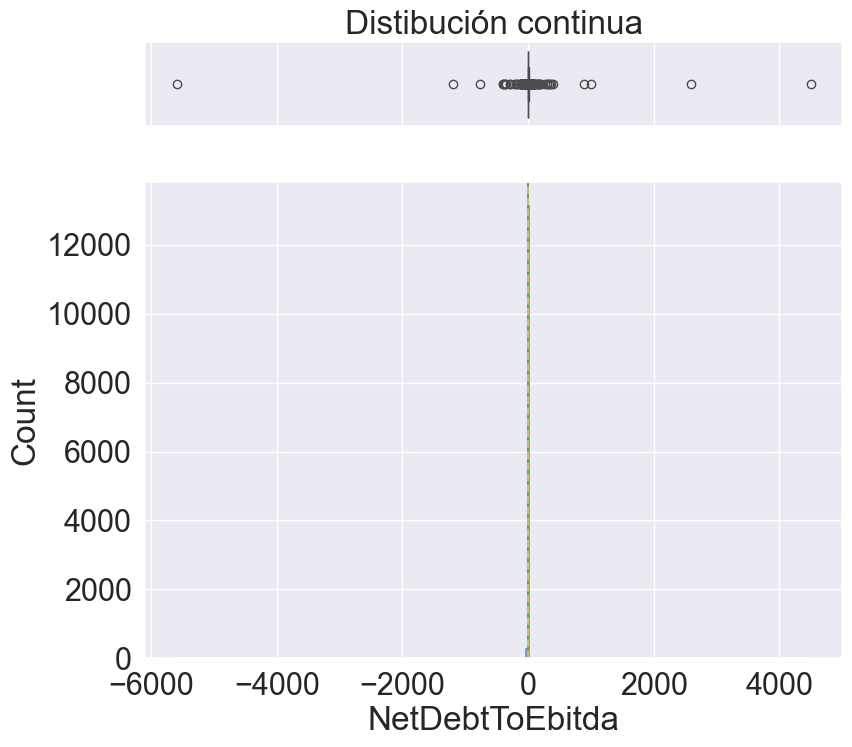

In [20]:
# Graficar
columna_a_graficar = 'NetDebtToEbitda' # indicar columna para el grafico
plot(df_transformed[columna_a_graficar])

In [21]:
# Transformaciones logarítmicas
columnas_a_transformar = [ 
    'CurrentRatio',
    'RelativeAssets',
    'RelativeRevenue'
    ]
for columna in columnas_a_transformar:
    df_transformed[f'{columna}_log'] = np.log(df_transformed[columna])
    df_transformed.drop(columna, axis=1, inplace=True)

# Coeficientes de asimetria actualizado
df_transformed.select_dtypes(include="number").skew().sort_values(ascending=False)

c:\Users\sebas\anaconda3\envs\ucm-dev\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


TrailingPE                116.472050
Dividends                  57.741179
CapExToRevenue             33.438357
Revenue_QoQ                20.235266
PriceToBook                17.215509
MarketCap                  13.775378
EnterpriseValue            13.661300
Close                      13.004281
Revenue_YoY                12.744436
MonthlyVariance            12.689156
NetIncome_TTM              11.748792
OperatingCashFlow_TTM      10.831195
OperatingIncome_TTM        10.482553
EBITDA_TTM                 10.262475
CurrentDebt                 9.996846
GrossProfit_TTM             9.763053
FreeCashFlow_TTM            9.123380
BasicAverageShares_TTM      8.580725
DebtToEquity                7.879379
ReturnOnAssets              7.390955
StockholdersEquity          7.000909
TotalRevenue_TTM            6.257018
CurrentLiabilities          5.769720
Ebitda_QoQ                  5.468308
Ebitda_YoY                  5.409424
CurrentAssets               4.963278
CashAndCashEquivalents      4.831470
T

In [22]:
# Definir columnas que saltean la "winsorización"
columnas_intactas = cols_monetarias + [
    'Close',    
    'TrailingPE',
    'EnterpriseToEbitda',
    'PriceToBook',
    'Date', 
    'Ticker',
    'Dividends'        
    ]

# Separar el dataset
df_passthrough = df_transformed[columnas_intactas].copy()
df_transformed_features = df_transformed.drop(columns=columnas_intactas)

## Gestión de Outliers

Se winsorizan los valores atipicos en las variables continuas que cumplan los siguientes criterios:

Para variables simetricas:
* A mas de 3 desviaciones tipicas de la media.
* Mas de 3 rangos intercuartilicos.

Para variables asimetricas (modulo del coeficiente de asimetrica mayor a 1):
* A mas de 3 MADs de la mediana.
* Mas de 3 rangos intercuartilicos.

In [23]:
# Outliers
df_cont_transformed = df_transformed_features.select_dtypes(include="number")
df_winsor = df_cont_transformed.apply(lambda x: gestiona_outliers(x, clas='winsor'))

OperatingMargins
ProfitMargins
ReturnOnEquity
ReturnOnAssets
DebtToEquity
Revenue_YoY
Revenue_QoQ
Ebitda_YoY
Ebitda_QoQ
Fcf_YoY
Fcf_QoQ
CapEx_YoY
CapEx_QoQ
NetDebtToEbitda
FcfToEbitda
CapExToRevenue
MonthlyReturn
MonthlyVariance
MarketCovariance
YearsSinceAdded
CurrentRatio_log
RelativeAssets_log
RelativeRevenue_log


In [24]:
# Coeficientes de asimetria luego de winsorizar
df_winsor.skew().sort_values(ascending=False)

MonthlyVariance        1.685136
YearsSinceAdded        1.197407
Revenue_YoY            1.121637
MarketCovariance       1.118848
CapExToRevenue         0.803127
ReturnOnAssets         0.597489
Fcf_QoQ                0.511212
MonthlyReturn          0.448823
Ebitda_YoY             0.436771
Fcf_YoY                0.365035
Ebitda_QoQ             0.323647
NetDebtToEbitda        0.309060
Revenue_QoQ            0.281708
OperatingMargins       0.213805
RelativeRevenue_log    0.143763
DebtToEquity          -0.006308
RelativeAssets_log    -0.023922
ProfitMargins         -0.029641
ReturnOnEquity        -0.061894
FcfToEbitda           -0.205497
CurrentRatio_log      -0.405757
CapEx_QoQ             -0.464780
CapEx_YoY             -0.913211
dtype: float64

Cont


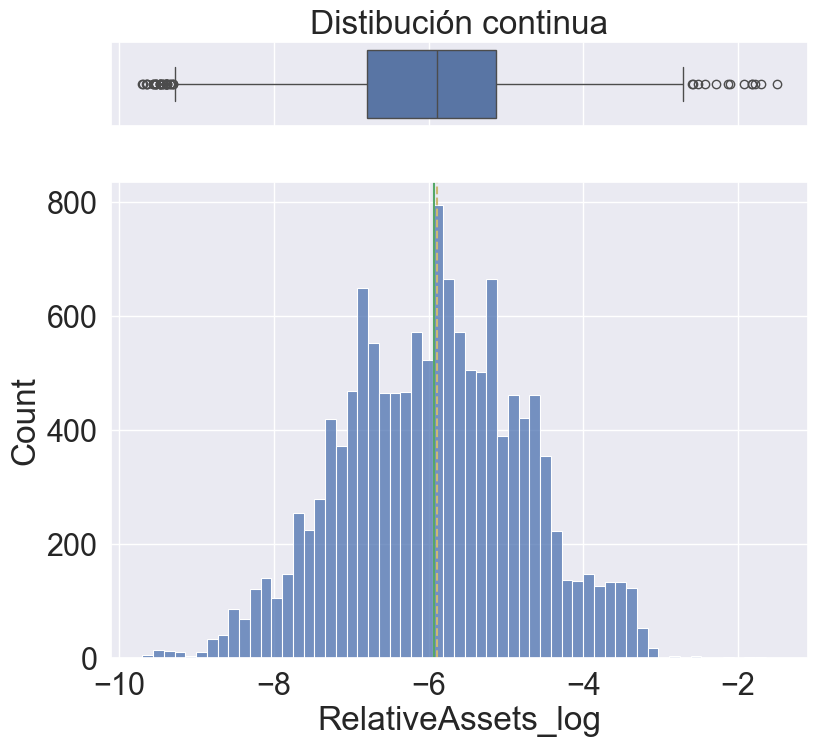

In [25]:
# Visualizar cambios
columna_a_graficar = 'RelativeAssets_log' # indicar columna para el grafico
plot(df_winsor[columna_a_graficar])

In [26]:
df_winsor.describe().T

,count,mean,std,min,25%,50%,75%,max
OperatingMargins,13566.0,0.192609,0.159085,-0.389165,0.105774,0.177899,0.268918,0.762752
ProfitMargins,13566.0,0.129802,0.154928,-0.367545,0.057767,0.119336,0.198889,0.623956
ReturnOnEquity,13566.0,0.166452,0.335293,-0.655745,0.062529,0.146156,0.301548,1.019245
ReturnOnAssets,13566.0,0.072918,0.074983,-0.177856,0.032027,0.058523,0.101877,0.312048
DebtToEquity,13566.0,0.880571,1.522125,-2.741088,0.367976,0.714726,1.399678,4.496552
Revenue_YoY,13566.0,0.108879,0.156144,-0.432221,0.037880,0.086250,0.193514,0.661548
Revenue_QoQ,13566.0,0.026108,0.075156,-0.181033,-0.006118,0.024264,0.052055,0.226891
Ebitda_YoY,13566.0,0.155728,0.297397,-0.678313,0.028653,0.124690,0.258520,0.948241
Ebitda_QoQ,13566.0,0.043661,0.210614,-0.497294,-0.040333,0.023675,0.111767,0.568254
Fcf_YoY,13566.0,0.088373,0.665734,-1.541410,-0.188896,0.040298,0.261318,1.612290


## Concatenación final de columnas

In [27]:
df_non_numeric_transformed = df_transformed_features.select_dtypes(exclude='number')
# Se unen variables contínuas transformadas y variables no numéricas
df_combined = pd.concat([df_non_numeric_transformed, df_winsor], axis=1)

# Unir con las columnas que fueron salteadas
df_final = pd.concat([df_passthrough, df_combined], axis=1)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13566 entries, 0 to 13565
Data columns (total 54 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   CashAndCashEquivalents  13566 non-null  float64       
 1   CurrentDebt             13566 non-null  float64       
 2   LongTermDebt            13566 non-null  float64       
 3   TotalDebt               13566 non-null  float64       
 4   StockholdersEquity      13566 non-null  float64       
 5   TotalAssets             13566 non-null  float64       
 6   CurrentAssets           13566 non-null  float64       
 7   CurrentLiabilities      13566 non-null  float64       
 8   OperatingCashFlow_TTM   13566 non-null  float64       
 9   InvestingCashFlow_TTM   13566 non-null  float64       
 10  FinancingCashFlow_TTM   13566 non-null  float64       
 11  FreeCashFlow_TTM        13566 non-null  float64       
 12  CapitalExpenditure_TTM  13566 non-null  float6

In [28]:
# Guardar datos extraidos en fichero clean_data
df_final.to_parquet(f"{data_folder}/clean_data.parquet")